# Project 1

OPIM 5604 - Predictive Modeling

Group 7:
- Rachel Scott
- Amanda Carducci
- Azucena Moreno
- Emi Erekosima
- George Khramtchenko
- Andrew Ghali
- Alex Schwarz

# Environment Setup

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# !pip install scikit-learn
from sklearn.preprocessing import PowerTransformer

pd.set_option('display.max_columns', None)

# Read in the data

In [174]:
# Process taken from Class OPIM 5512 (Data Science Using Python)

# https://drive.google.com/file/d/1Lql6vPab-jO9gmDEl7BCrKML4jtBZSP8/view?usp=sharing

# Download data to Google Colab Environment
!gdown 1Lql6vPab-jO9gmDEl7BCrKML4jtBZSP8

Downloading...
From: https://drive.google.com/uc?id=1Lql6vPab-jO9gmDEl7BCrKML4jtBZSP8
To: /content/listings.csv
100% 22.7M/22.7M [00:00<00:00, 62.0MB/s]


In [175]:
# Read in the CSV
df = pd.read_csv('listings.csv')

In [176]:
# Get a summary of our dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10669 entries, 0 to 10668
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10669 non-null  int64  
 1   listing_url                                   10669 non-null  object 
 2   scrape_id                                     10669 non-null  int64  
 3   last_scraped                                  10669 non-null  object 
 4   source                                        10669 non-null  object 
 5   name                                          10669 non-null  object 
 6   description                                   10469 non-null  object 
 7   neighborhood_overview                         4594 non-null   object 
 8   picture_url                                   10669 non-null  object 
 9   host_id                                       10669 non-null 

In [177]:
# Set a list of my original columns 0-26
cols = list(df.iloc[:, 0:27].columns)
cols

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified']

# Data Exploration

In [178]:
# Check the head of the data
df[cols].head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified
0,63413,https://www.airbnb.com/rooms/63413,20250619031344,2025-06-19,city scrape,Charming Room on Riviera di Chiaia,Centrally located and at walking distance to t...,The house is located in a lively and popular n...,https://a0.muscache.com/pictures/389538/99361e...,309483,https://www.airbnb.com/users/show/309483,Paola,2010-12-04,"Campania, Italy",Le Stanze dei Pollano - this is our website,within an hour,100%,100%,f,https://a0.muscache.com/im/pictures/user/9245d...,https://a0.muscache.com/im/pictures/user/9245d...,NaN,1.0,2.0,"['email', 'phone']",t,t
1,74364,https://www.airbnb.com/rooms/74364,20250619031344,2025-06-19,city scrape,Cozy place in a princely Palace inside Old Town,"Davide hosts as an individual, and is solely r...",The flat is in the OLD TOWN od Napoli with 2 m...,https://a0.muscache.com/pictures/c8a48f3d-1be3...,289412,https://www.airbnb.com/users/show/289412,Davide,2010-11-17,"Naples, Italy","Architecture, art, archeology, good food.",within an hour,100%,100%,NaN,https://a0.muscache.com/im/pictures/user/ad87f...,https://a0.muscache.com/im/pictures/user/ad87f...,NaN,13.0,13.0,"['email', 'phone']",t,t
2,76993,https://www.airbnb.com/rooms/76993,20250619031344,2025-06-19,city scrape,"Central Cebollitas B&B, spacious private ensuite.","A bright, sunny home in vomero area (on a hill...","La casa di Cebollitas si trova a Napoli, Campa...",https://a0.muscache.com/pictures/miso/Hosting-...,411650,https://www.airbnb.com/users/show/411650,Cebollitas,2011-02-26,"Naples, Italy",Cebollitas is a homely modern b&b situated in...,within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/11114...,https://a0.muscache.com/im/pictures/user/11114...,NaN,4.0,4.0,"['email', 'phone']",t,t
3,77009,https://www.airbnb.com/rooms/77009,20250619031344,2025-06-19,city scrape,"Central Cebollitas B&B Napoli,single/double room",NaN,"La casa di Cebollitas si trova a Napoli, Campa...",https://a0.muscache.com/pictures/airflow/Hosti...,411650,https://www.airbnb.com/users/show/411650,Cebollitas,2011-02-26,"Naples, Italy",Cebollitas is a homely modern b&b situated in...,within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/11114...,https://a0.muscache.com/im/pictures/user/11114...,NaN,4.0,4.0,"['email', 'phone']",t,t
4,77010,https://www.airbnb.com/rooms/77010,20250619031344,2025-06-19,city scrape,"central Cebollitas B&B , large single/double","A bright, sunny home in vomero area (on a hill...","It's a safe and friendly neighbourhood, on the...",https://a0.muscache.com/pictures/airflow/Hosti...,411650,https://www.airbnb.com/users/show/411650,Cebollitas,2011-02-26,"Naples, Italy",Cebollitas is a homely modern b&b situated in...,within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/11114...,https://a0.muscache.com/im/pictures/user/11114...,NaN,4.0,4.0,"['email', 'phone']",t,t


id, listing_url, scrape_id, last_scraped, name, description, neighborhood_overview, picture_url, host_id, host_url, host_name, host_about, host_thumbnail_url, host_picture_url are all informational and can likely be dropped, however before doing so it may be beneficial to create a binary variable for if the description exists as no description might have an impact on price.

In [179]:
# Create a binary variable called "description_present" as 1 if true and 0  if false
df['description_present'] = np.where(df['description'].isnull(), 0, 1)

# add description_present to cols
cols.append('description_present')

In [180]:
# Drop unnecessary columns
drop_cols =['id',
            'listing_url',
            'scrape_id',
            'last_scraped',
            'name',
            'description',
            'neighborhood_overview',
            'picture_url',
            'host_id',
            'host_url',
            'host_name',
            'host_about',
            'host_thumbnail_url',
            'host_picture_url']

df = df.drop(drop_cols,
             axis=1)

# update our working column list
cols = [c for c in cols if c not in drop_cols]
cols

['source',
 'host_since',
 'host_location',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'description_present']

In [181]:
# Get df info
df[cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10669 entries, 0 to 10668
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   source                     10669 non-null  object 
 1   host_since                 10667 non-null  object 
 2   host_location              7078 non-null   object 
 3   host_response_time         8369 non-null   object 
 4   host_response_rate         8369 non-null   object 
 5   host_acceptance_rate       9273 non-null   object 
 6   host_is_superhost          10229 non-null  object 
 7   host_neighbourhood         168 non-null    object 
 8   host_listings_count        10667 non-null  float64
 9   host_total_listings_count  10667 non-null  float64
 10  host_verifications         10667 non-null  object 
 11  host_has_profile_pic       10667 non-null  object 
 12  host_identity_verified     10667 non-null  object 
 13  description_present        10669 non-null  int

In [182]:
# Take a look at the data after dropping
df[cols].head(5)

,source,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,description_present
0,city scrape,2010-12-04,"Campania, Italy",within an hour,100%,100%,f,NaN,1.0,2.0,"['email', 'phone']",t,t,1
1,city scrape,2010-11-17,"Naples, Italy",within an hour,100%,100%,NaN,NaN,13.0,13.0,"['email', 'phone']",t,t,1
2,city scrape,2011-02-26,"Naples, Italy",within an hour,100%,97%,t,NaN,4.0,4.0,"['email', 'phone']",t,t,1
3,city scrape,2011-02-26,"Naples, Italy",within an hour,100%,97%,t,NaN,4.0,4.0,"['email', 'phone']",t,t,0
4,city scrape,2011-02-26,"Naples, Italy",within an hour,100%,97%,t,NaN,4.0,4.0,"['email', 'phone']",t,t,1


In [183]:
# I notice that host_response_rate and host_acceptance_rate are percentages, but have the % symbol.
# Let's remove the % from both rows and update it to numeric
df['host_response_rate'] = df['host_response_rate'].str.replace('%', '').astype(float)
df['host_acceptance_rate'] = df['host_acceptance_rate'].str.replace('%', '').astype(float)

In [184]:
# Transform host_since from a date to a total number of days the host has been a host since the report date of 2025-06-19
df['host_since'] = pd.to_datetime(df['host_since'])
df['host_since'] = pd.to_numeric((pd.to_datetime('2025-06-19') - df['host_since']).dt.days)

In [185]:
# Get a summary of unique values for each column
df[cols].nunique()

,0
source,2
host_since,2971
host_location,146
host_response_time,4
host_response_rate,47
host_acceptance_rate,87
host_is_superhost,2
host_neighbourhood,27
host_listings_count,65
host_total_listings_count,73


# Missing Data

## Missing Data Detection

In [186]:
# Get a null summary
df[cols].isnull().sum()

,0
source,0
host_since,2
host_location,3591
host_response_time,2300
host_response_rate,2300
host_acceptance_rate,1396
host_is_superhost,440
host_neighbourhood,10501
host_listings_count,2
host_total_listings_count,2


## Handle Missing Data

### Part 1

(Alex Schwarz and Amanda Carducci)

In [187]:
# Starting with host_listing_count, there are 2 missing for this. Let's remove rows where host_listing_count is null
df = df.dropna(subset=['host_listings_count'])

In [188]:
# Check the null summary
df[cols].isnull().sum()

,0
source,0
host_since,0
host_location,3589
host_response_time,2298
host_response_rate,2298
host_acceptance_rate,1394
host_is_superhost,440
host_neighbourhood,10499
host_listings_count,0
host_total_listings_count,0


In [189]:
# host_neighbourhood has mostly null values, so that's likely not going to be useful. Let's drop that
df = df.drop(['host_neighbourhood'], axis=1)

# let's update our cols list too
cols.remove('host_neighbourhood')

In [190]:
# Looking at host_location, while it would be nice to keep it, having 146 categorical places would be too computationally expensive, let's remove this column
df = df.drop(['host_location'], axis=1)

# update our cols list too
cols.remove('host_location')

In [191]:
# What are the response time value counts
df['host_response_time'].value_counts()

,count
host_response_time,
within an hour,7210
within a few hours,636
within a day,312
a few days or more,211


In [192]:
# Look at host_response_time and host_response_rate when they're null
df[(df['host_response_time'].isnull()) & (df['host_response_rate'].isnull())]

,source,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,description_present
6,previous scrape,5103.0,NaN,NaN,NaN,f,2.0,5.0,"['email', 'phone']",t,t,"Napoli, Campania, Italy",San Lorenzo,NaN,40.853920,14.256730,Entire rental unit,Entire home/apt,6,NaN,2 baths,3.0,NaN,"[""TV with standard cable"", ""Bed linens"", ""Kitc...",NaN,31,730,31,31,730,730,31.0,730.0,NaN,t,30,60,90,365,2025-06-19,9,0,0,196,0,0,NaN,2017-12-10,2021-11-01,4.22,4.11,4.56,4.22,4.22,4.89,4.33,NaN,t,2,2,0,0,0.10,1
21,city scrape,4910.0,NaN,NaN,100.0,t,2.0,6.0,"['email', 'phone']",t,t,"Naples, Campania, Italy",Pendino,NaN,40.851270,14.258540,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Shampoo"", ""Cooking basics"", ""Kitchen"", ""Hot ...",$75.00,31,1125,31,31,1125,1125,31.0,1125.0,NaN,t,29,59,89,364,2025-06-19,372,12,0,195,24,255,19125.0,2012-04-16,2024-11-04,4.76,4.83,4.85,4.92,4.95,4.85,4.75,NaN,f,2,2,0,0,2.32,0
22,city scrape,4910.0,NaN,NaN,100.0,t,2.0,6.0,"['email', 'phone']",t,t,"Naples, Campania, Italy",San Lorenzo,NaN,40.850690,14.258840,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Shampoo"", ""Bed linens"", ""Cooking basics"", ""K...",$75.00,31,1125,31,31,1125,1125,31.0,1125.0,NaN,t,29,59,89,364,2025-06-19,369,12,0,195,29,255,19125.0,2012-07-24,2025-01-02,4.78,4.84,4.84,4.92,4.93,4.86,4.77,NaN,f,2,2,0,0,2.35,0
25,city scrape,4746.0,NaN,NaN,NaN,f,2.0,3.0,"['email', 'phone']",t,t,"Naples, Campania, Italy",San Ferdinando,NaN,40.833680,14.251360,Private room in bed and breakfast,Private room,4,1.0,1 private bath,1.0,1.0,"[""Shampoo"", ""TV with standard cable"", ""Washer""...",$299.00,1,30,1,4,4,4,2.6,4.0,NaN,t,4,12,14,41,2025-06-19,1,0,0,41,0,0,0.0,2014-07-17,2014-07-17,5.00,5.00,5.00,5.00,5.00,5.00,5.00,IT063049C1G6M3SH86,f,2,0,2,0,0.01,0
26,city scrape,4730.0,NaN,NaN,NaN,f,2.0,2.0,"['email', 'phone']",t,t,"Naples, Campania, Italy",San Ferdinando,NaN,40.838300,14.248160,Entire loft,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[""Shampoo"", ""TV with standard cable"", ""Bed lin...",$100.00,2,28,2,2,1125,1125,2.0,1125.0,NaN,t,6,12,32,253,2025-06-19,41,0,0,110,0,0,0.0,2013-07-24,2022-09-28,4.76,4.66,4.80,4.88,4.85,4.95,4.68,IT063049C1NSTWT89K,f,2,2,0,0,0.28,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10664,city scrape,1240.0,NaN,NaN,NaN,f,4.0,4.0,['phone'],t,f,NaN,Montecalvario,NaN,40.846442,14.248110,Entire condo,Entire home/apt,8,3.0,3 baths,3.0,4.0,"[""Shampoo"", ""Bed linens"", ""Hot water"", ""Carbon...",$266.00,1,28,1,1,1125,1125,1.0,1125.0,NaN,t,27,57,87,362,2025-06-19,0,0,0,193,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"I applied for a CIN, but haven’t received it yet",t,3

In [193]:
# When host_response_time is null, so is host_response_rate, so it can be safe to assume no respones
# Fill null host_response_time with "none"
df['host_response_time'] = df['host_response_time'].fillna('none')

# Fill host_response_rate with 0
df['host_response_rate'] = df['host_response_rate'].fillna(0)

In [194]:
# Check the null summary
df[cols].isnull().sum()

,0
source,0
host_since,0
host_response_time,0
host_response_rate,0
host_acceptance_rate,1394
host_is_superhost,440
host_listings_count,0
host_total_listings_count,0
host_verifications,0
host_has_profile_pic,0


In [195]:
# Check the amount of null values for host_is_superhost
print(df["host_is_superhost"].isnull().sum() / len(df))

0.04124871097778195


In [196]:
# For host_is_superhost, there aren't many records, just 4%, so let's remove those null rows
df = df.dropna(subset=['host_is_superhost'])

In [197]:
# Check remaining nulls
df[cols].isnull().sum()

,0
source,0
host_since,0
host_response_time,0
host_response_rate,0
host_acceptance_rate,1374
host_is_superhost,0
host_listings_count,0
host_total_listings_count,0
host_verifications,0
host_has_profile_pic,0


In [198]:
# So that we can maintain the most data, let's fill in the acceptance rate with the average
df['host_acceptance_rate'] = df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].mean())

In [199]:
# Verify no missing values
df[cols].isnull().sum()

,0
source,0
host_since,0
host_response_time,0
host_response_rate,0
host_acceptance_rate,0
host_is_superhost,0
host_listings_count,0
host_total_listings_count,0
host_verifications,0
host_has_profile_pic,0


In [200]:
# Check how many we're left with
df.shape

(10227, 64)

In [201]:
# One last thing I noticed. host_verifications seems to be a nested list. Let's remove [, ', and ] from this column
df['host_verifications'] = df['host_verifications'].str.replace(r"[\[\]']", '', regex=True)
df['host_verifications'].head(5)

,host_verifications
0,"email, phone"
2,"email, phone"
3,"email, phone"
4,"email, phone"
5,"email, phone, work_email"


In [202]:
# Let's create dummy variables
df_host_verifications = df['host_verifications'].str.get_dummies(sep=', ')

# add a prefix to the new columns
df_host_verifications = df_host_verifications.add_prefix('host_verifications_')

# join back to original df
df = df.join(df_host_verifications)

In [203]:
# drop the original column
df = df.drop(['host_verifications'], axis=1)

# remove host_verifications from our cols list
cols.remove('host_verifications')

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10227 entries, 0 to 10668
Data columns (total 66 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   source                                        10227 non-null  object 
 1   host_since                                    10227 non-null  float64
 2   host_response_time                            10227 non-null  object 
 3   host_response_rate                            10227 non-null  float64
 4   host_acceptance_rate                          10227 non-null  float64
 5   host_is_superhost                             10227 non-null  object 
 6   host_listings_count                           10227 non-null  float64
 7   host_total_listings_count                     10227 non-null  float64
 8   host_has_profile_pic                          10227 non-null  object 
 9   host_identity_verified                        10227 non-null  obje

In [205]:
# Update description_present, host_verification_email, host_verification_phone, host_verification_work_email all as string
df['description_present'] = df['description_present'].astype(str)
df['host_verifications_email'] = df['host_verifications_email'].astype(str)
df['host_verifications_phone'] = df['host_verifications_phone'].astype(str)
df['host_verifications_work_email'] = df['host_verifications_work_email'].astype(str)

In [206]:
df.sample(5)

,source,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,description_present,host_verifications_email,host_verifications_phone,host_verifications_work_email
8860,city scrape,815.0,within an hour,100.0,100.0,f,2.0,2.0,f,f,NaN,Zona Industriale,NaN,40.853136,14.271073,Private room in bed and breakfast,Private room,2,1.0,1 private bath,1.0,1.0,"[""Shampoo"", ""Bed linens"", ""Exterior security c...",$108.00,1,28,1,2,28,28,1.1,28.0,NaN,t,26,39,53,190,2025-06-19,1,1,0,159,0,6,648.0,2025-05-05,2025-05-05,5.00,5.00,5.00,5.00,5.00,3.00,5.00,IT063049C1CCVMHG6J,t,2,0,2,0,0.65,1,1,1,0
8173,city scrape,339.0,none,0.0,100.0,f,1.0,1.0,t,t,NaN,San Lorenzo,NaN,40.854010,14.256825,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,1.0,"[""Shampoo"", ""TV"", ""Washer"", ""Bidet"", ""Kitchen""...",$93.00,1,365,2,2,365,365,2.0,365.0,NaN,t,20,43,72,334,2025-06-19,5,5,0,167,4,30,2790.0,2024-08-05,2025-04-11,4.20,4.60,4.00,4.20,4.80,4.80,4.40,IT063049C2BNW3CPS9,t,1,1,0,0,0.47,1,1,1,0
3501,city scrape,2083.0,within a few hours,100.0,100.0,f,4.0,5.0,t,t,NaN,Vicaria,NaN,40.858980,14.272260,Private room in rental unit,Private room,1,1.0,1 private bath,1.0,1.0,"[""Shampoo"", ""Exterior security cameras on prop...",$76.00,1,45,1,2,45,45,1.4,45.0,NaN,t,19,49,79,161,2025-06-19,1,0,0,160,0,0,0.0,2022-04-11,2022-04-11,5.00,5.00,5.00,5.00,5.00,5.00,5.00,IT063049B47CHQP5PT,t,4,0,4,0,0.03,1,1,1,0
1269,city scrape,4808.0,within an hour,100.0,97.0,f,3.0,4.0,t,t,"Napoli, Campania, Italy",San Lorenzo,NaN,40.851680,14.262580,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,2.0,"[""TV with standard cable"", ""Bed linens"", ""Cook...",$92.00,2,30,2,3,30,30,2.2,30.0,NaN,t,8,18,40,313,2025-06-19,364,45,6,144,53,255,23460.0,2018-05-22,2025-06-13,4.70,4.69,4.58,4.77,4.94,4.68,4.69,IT063049C2QY4QWPA5,t,3,3,0,0,4.22,1,1,1,0
4494,city scrape,2764.0,none,0.0,100.0,t,3.0,3.0,t,t,"Napoli, Campania, Italy",Pendino,NaN,40.849482,14.262576,Entire rental unit,Entire home/apt,4,1.5,1.5 baths,1.0,2.0,"[""Shampoo"", ""Bed linens"", ""Exterior security c...",$78.00,2,365,1,1,365,365,1.0,365.0,NaN,t,0,0,0,0,2025-06-19,64,25,0,0,30,150,11700.0,2023-05-18,2025-02-27,4.95,4.94,4.97,4.95,5.00,4.91,4.95,IT063049C1AO4FMUQI,t,3,3,0,0,2.51,1,1,1,0


### Part 2

(Acuzena Moreno and Andrew Ghali)

In [207]:
# Select only columns 27–40
cols2 = ['neighbourhood','neighbourhood_cleansed','neighbourhood_group_cleansed','latitude','longitude','property_type','room_type','accommodates','bathrooms','bathrooms_text','bedrooms','beds','amenities','price']
df[cols2]
print(df[cols2].shape)

(10227, 14)


In [208]:
print("\nRaw price values (before cleaning):")
print(df['price'].head(10))


Raw price values (before cleaning):
0      $53.00
2      $56.00
3      $42.00
4      $43.00
5      $58.00
6         NaN
7     $247.00
8     $103.00
9      $85.00
10    $100.00
Name: price, dtype: object


In [209]:
# Force text, remove symbols, convert to numeric
df['price'] = df['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Drop rows with missing or zero price
df = df.dropna(subset=['price'])
df = df[df['price'] > 0]
print("\nCleaned price values:")
print(df['price'].head(10))
print("Price dtype:", df['price'].dtype)
print("Shape after price cleaning:", df.shape)


Cleaned price values:
0      53.0
2      56.0
3      42.0
4      43.0
5      58.0
7     247.0
8     103.0
9      85.0
10    100.0
11    105.0
Name: price, dtype: float64
Price dtype: float64
Shape after price cleaning: (9088, 66)


In [210]:
cols_to_fill = ['bathrooms', 'bedrooms', 'beds']
for col in cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [211]:
df = df.drop(columns=['neighbourhood','neighbourhood_group_cleansed','bathrooms_text'])
cols2.remove('neighbourhood')
cols2.remove('neighbourhood_group_cleansed')
cols2.remove('bathrooms_text')

print("Shape after dropping irrelevant columns:", df.shape)

Shape after dropping irrelevant columns: (9088, 63)


In [212]:
# Handle remaining missing values
for col in df[cols2].columns:
    if df[col].isnull().any():
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9088 entries, 0 to 10668
Data columns (total 63 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   source                                        9088 non-null   object 
 1   host_since                                    9088 non-null   float64
 2   host_response_time                            9088 non-null   object 
 3   host_response_rate                            9088 non-null   float64
 4   host_acceptance_rate                          9088 non-null   float64
 5   host_is_superhost                             9088 non-null   object 
 6   host_listings_count                           9088 non-null   float64
 7   host_total_listings_count                     9088 non-null   float64
 8   host_has_profile_pic                          9088 non-null   object 
 9   host_identity_verified                        9088 non-null   objec

### Part 3

(Emi Erekosima and Rachel Scott)

In [214]:
cols3 = ['minimum_nights',
         'maximum_nights',
         'minimum_minimum_nights',
         'maximum_minimum_nights',
         'minimum_maximum_nights',
         'maximum_maximum_nights',
         'minimum_nights_avg_ntm',
         'maximum_nights_avg_ntm',
         'calendar_updated',
         'has_availability',
         'availability_30',
         'availability_60',
         'availability_90',
         'availability_365',
         'calendar_last_scraped',
         'number_of_reviews',
         'number_of_reviews_ltm',
         'number_of_reviews_l30d',
         'availability_eoy']
df[cols3]
print(df[cols3])

       minimum_nights  maximum_nights  minimum_minimum_nights  \
0                   3              60                       3   
2                   3              30                       1   
3                   3              60                       1   
4                   3              30                       1   
5                   2              28                       2   
...               ...             ...                     ...   
10664               1              28                       1   
10665               2              28                       2   
10666               2              28                       2   
10667               1             365                       1   
10668               1              30                       1   

       maximum_minimum_nights  minimum_maximum_nights  maximum_maximum_nights  \
0                          12                    1125                    1125   
2                           4                    1125    

In [215]:
print(df[cols3].info())

<class 'pandas.core.frame.DataFrame'>
Index: 9088 entries, 0 to 10668
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   minimum_nights          9088 non-null   int64  
 1   maximum_nights          9088 non-null   int64  
 2   minimum_minimum_nights  9088 non-null   int64  
 3   maximum_minimum_nights  9088 non-null   int64  
 4   minimum_maximum_nights  9088 non-null   int64  
 5   maximum_maximum_nights  9088 non-null   int64  
 6   minimum_nights_avg_ntm  9088 non-null   float64
 7   maximum_nights_avg_ntm  9088 non-null   float64
 8   calendar_updated        0 non-null      float64
 9   has_availability        9061 non-null   object 
 10  availability_30         9088 non-null   int64  
 11  availability_60         9088 non-null   int64  
 12  availability_90         9088 non-null   int64  
 13  availability_365        9088 non-null   int64  
 14  calendar_last_scraped   9088 non-null   obje

In [216]:
# Check for missing values in each column
print("Missing values per column:")
print(df[cols3].isnull().sum())

# Check the total number of missing values in the DataFrame
print("\nTotal missing values in the dataset:")
print(df[cols3].isnull().sum().sum())

# calendar updated has 10669 missing values so its an empty row and has availability has 124 missing values
# we will get rid of the empty column
# it is important for this project to know if a place has availability or not so we drop the row where availability info is not given to us in the next chunck

Missing values per column:
minimum_nights               0
maximum_nights               0
minimum_minimum_nights       0
maximum_minimum_nights       0
minimum_maximum_nights       0
maximum_maximum_nights       0
minimum_nights_avg_ntm       0
maximum_nights_avg_ntm       0
calendar_updated          9088
has_availability            27
availability_30              0
availability_60              0
availability_90              0
availability_365             0
calendar_last_scraped        0
number_of_reviews            0
number_of_reviews_ltm        0
number_of_reviews_l30d       0
availability_eoy             0
dtype: int64

Total missing values in the dataset:
9115


In [217]:
df[cols3].info()

<class 'pandas.core.frame.DataFrame'>
Index: 9088 entries, 0 to 10668
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   minimum_nights          9088 non-null   int64  
 1   maximum_nights          9088 non-null   int64  
 2   minimum_minimum_nights  9088 non-null   int64  
 3   maximum_minimum_nights  9088 non-null   int64  
 4   minimum_maximum_nights  9088 non-null   int64  
 5   maximum_maximum_nights  9088 non-null   int64  
 6   minimum_nights_avg_ntm  9088 non-null   float64
 7   maximum_nights_avg_ntm  9088 non-null   float64
 8   calendar_updated        0 non-null      float64
 9   has_availability        9061 non-null   object 
 10  availability_30         9088 non-null   int64  
 11  availability_60         9088 non-null   int64  
 12  availability_90         9088 non-null   int64  
 13  availability_365        9088 non-null   int64  
 14  calendar_last_scraped   9088 non-null   obje

In [218]:
# Find the index of rows with missing values in the 'has_availability' column
missing_availability_indices = df[df['has_availability'].isnull()].index

# Drop the rows with missing 'key' values
df.drop(missing_availability_indices, inplace=True)

# Drop columns that are entirely null
df.dropna(axis=1, how='all', inplace=True)

cols3.remove('calendar_updated')

# Verify that the rows have been dropped by checking for missing 'has_availability' values again
print("\nMissing values after dropping rows with missing availability info and empty columns:")
print(df.isnull().sum())

# Verify the new shape of the DataFrame
print("\nShape of DataFrame after dropping rows with missing availability info and empty columns:")
print(df.shape)


Missing values after dropping rows with missing availability info and empty columns:
source                              0
host_since                          0
host_response_time                  0
host_response_rate                  0
host_acceptance_rate                0
                                 ... 
reviews_per_month                2070
description_present                 0
host_verifications_email            0
host_verifications_phone            0
host_verifications_work_email       0
Length: 62, dtype: int64

Shape of DataFrame after dropping rows with missing availability info and empty columns:
(9061, 62)


In [219]:
df[cols3].info()

<class 'pandas.core.frame.DataFrame'>
Index: 9061 entries, 0 to 10668
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   minimum_nights          9061 non-null   int64  
 1   maximum_nights          9061 non-null   int64  
 2   minimum_minimum_nights  9061 non-null   int64  
 3   maximum_minimum_nights  9061 non-null   int64  
 4   minimum_maximum_nights  9061 non-null   int64  
 5   maximum_maximum_nights  9061 non-null   int64  
 6   minimum_nights_avg_ntm  9061 non-null   float64
 7   maximum_nights_avg_ntm  9061 non-null   float64
 8   has_availability        9061 non-null   object 
 9   availability_30         9061 non-null   int64  
 10  availability_60         9061 non-null   int64  
 11  availability_90         9061 non-null   int64  
 12  availability_365        9061 non-null   int64  
 13  calendar_last_scraped   9061 non-null   object 
 14  number_of_reviews       9061 non-null   int6

### Part 4

(George Khramtchenko)

In [220]:
cols4 = ['number_of_reviews_ly',
         'estimated_occupancy_l365d',
         'estimated_revenue_l365d',
         'first_review',
         'last_review',
         'review_scores_rating',
         'review_scores_accuracy',
         'review_scores_cleanliness',
         'review_scores_checkin',
         'review_scores_communication',
         'review_scores_location',
         'review_scores_value',
         'license',
         'instant_bookable',
         'calculated_host_listings_count',
         'calculated_host_listings_count_entire_homes',
         'calculated_host_listings_count_private_rooms',
         'calculated_host_listings_count_shared_rooms',
         'reviews_per_month']

In [221]:
df[cols4].info()

<class 'pandas.core.frame.DataFrame'>
Index: 9061 entries, 0 to 10668
Data columns (total 19 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   number_of_reviews_ly                          9061 non-null   int64  
 1   estimated_occupancy_l365d                     9061 non-null   int64  
 2   estimated_revenue_l365d                       9061 non-null   float64
 3   first_review                                  6991 non-null   object 
 4   last_review                                   6991 non-null   object 
 5   review_scores_rating                          6991 non-null   float64
 6   review_scores_accuracy                        6990 non-null   float64
 7   review_scores_cleanliness                     6990 non-null   float64
 8   review_scores_checkin                         6990 non-null   float64
 9   review_scores_communication                   6991 non-null   float

In [222]:
columns_to_drop = ['first_review', 'last_review', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'license', 'calculated_host_listings_count_shared_rooms']
df.drop(columns_to_drop, axis=1, inplace=True)

print("\nColumns after dropping ALL unused data columns:\n", df.columns)
print("\nShape of DataFrame after dropping ALL unused data columns:", df.shape)


Columns after dropping ALL unused data columns:
 Index(['source', 'host_since', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'calendar_last_scraped', 'number_of_reviews',
       'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy',
       'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d',

In [223]:
for col in columns_to_drop:
  cols4.remove(col)

In [224]:
# Check for missing values in each column
print("Missing values per column:")
print(df[cols4].isnull().sum())

# Check the total number of missing values in the DataFrame
print(f"\nTotal missing values in the dataset: {df[cols4].isnull().sum().sum()}")

Missing values per column:
number_of_reviews_ly                               0
estimated_occupancy_l365d                          0
estimated_revenue_l365d                            0
review_scores_rating                            2070
review_scores_value                             2070
instant_bookable                                   0
calculated_host_listings_count                     0
calculated_host_listings_count_entire_homes        0
calculated_host_listings_count_private_rooms       0
reviews_per_month                               2070
dtype: int64

Total missing values in the dataset: 6210


In [225]:
cols4

['number_of_reviews_ly',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'review_scores_rating',
 'review_scores_value',
 'instant_bookable',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'reviews_per_month']

In [226]:
df.dropna(inplace=True)
print(f"\nMissing values after dropping rows with missing data: \n{df.isnull().sum()}")
print(f"\nShape of DataFrame after dropping rows with missing data: {df.shape}")


Missing values after dropping rows with missing data: 
source                                          0
host_since                                      0
host_response_time                              0
host_response_rate                              0
host_acceptance_rate                            0
host_is_superhost                               0
host_listings_count                             0
host_total_listings_count                       0
host_has_profile_pic                            0
host_identity_verified                          0
neighbourhood_cleansed                          0
latitude                                        0
longitude                                       0
property_type                                   0
room_type                                       0
accommodates                                    0
bathrooms                                       0
bedrooms                                        0
beds                                        

In [227]:
print(f"View the data types of the columns before any changes, if necessary: \n{df[cols4].dtypes}")

View the data types of the columns before any changes, if necessary: 
number_of_reviews_ly                              int64
estimated_occupancy_l365d                         int64
estimated_revenue_l365d                         float64
review_scores_rating                            float64
review_scores_value                             float64
instant_bookable                                 object
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
reviews_per_month                               float64
dtype: object


In [228]:
# Convert the defined list of columns to int64 type; convert each column type if it exists
columns_to_convert = ['estimated_revenue_l365d']
for column in columns_to_convert:
    if column in df.columns:
        try:
            df[column] = pd.to_numeric(df[column], errors='coerce').astype('int64')
            print(f"Converted column '{column}' to int64 type.")
        except ValueError as e:
            print(f"Conversion of '{column}' to int64 after data cleaning failed: {e}")
    else:
        print(f"Column '{column}' not found in the DataFrame.")

Converted column 'estimated_revenue_l365d' to int64 type.


In [229]:
# Verify Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6991 entries, 0 to 10637
Data columns (total 53 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   source                                        6991 non-null   object 
 1   host_since                                    6991 non-null   float64
 2   host_response_time                            6991 non-null   object 
 3   host_response_rate                            6991 non-null   float64
 4   host_acceptance_rate                          6991 non-null   float64
 5   host_is_superhost                             6991 non-null   object 
 6   host_listings_count                           6991 non-null   float64
 7   host_total_listings_count                     6991 non-null   float64
 8   host_has_profile_pic                          6991 non-null   object 
 9   host_identity_verified                        6991 non-null   objec

In [230]:
df.head()

,source,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,reviews_per_month,description_present,host_verifications_email,host_verifications_phone,host_verifications_work_email
0,city scrape,5311.0,within an hour,100.0,100.0,f,1.0,2.0,t,t,Chiaia,40.83216,14.22642,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,"[""Shampoo"", ""TV"", ""Coffee maker"", ""Refrigerato...",53.0,3,60,3,12,1125,1125,3.3,1125.0,t,13,18,38,313,2025-06-19,132,14,4,144,18,84,4452,4.64,4.66,f,1,1,0,0.93,1,1,1,0
2,city scrape,5227.0,within an hour,100.0,97.0,t,4.0,4.0,t,t,Vomero,40.84568,14.22618,Private room in condo,Private room,4,1.0,1.0,2.0,"[""Shampoo"", ""Bed linens"", ""Hot water"", ""Coffee...",56.0,3,30,1,4,1125,1125,3.0,1125.0,t,3,25,26,278,2025-06-19,74,27,0,115,31,162,9072,4.97,4.95,f,4,1,3,0.57,1,1,1,0
3,city scrape,5227.0,within an hour,100.0,97.0,t,4.0,4.0,t,t,Vomero,40.84568,14.22618,Private room in condo,Private room,2,1.0,1.0,1.0,"[""Shampoo"", ""Hot water"", ""Coffee"", ""Dishwasher...",42.0,3,60,1,3,60,60,3.0,60.0,t,6,19,24,267,2025-06-19,223,41,2,103,41,246,10332,4.89,4.87,f,4,1,3,1.31,0,1,1,0
4,city scrape,5227.0,within an hour,100.0,97.0,t,4.0,4.0,t,t,Vomero,40.84568,14.22618,Private room in condo,Private room,2,1.0,1.0,2.0,"[""Shampoo"", ""Bed linens"", ""Oven"", ""Hot water"",...",43.0,3,30,1,3,1125,1125,3.0,1125.0,t,3,22,26,267,2025-06-19,150,32,0,103,31,192,8256,4.82,4.86,f,4,1,3,1.14,1,1,1,0
5,city scrape,5104.0,within a few hours,100.0,97.0,t,2.0,11.0,t,t,San Lorenzo,40.85028,14.25900,Entire condo,Entire home/apt,2,1.0,1.0,2.0,"[""Shampoo"", ""Cooking basics"", ""Oven"", ""Kitchen...",58.0,2,28,2,2,28,28,2.0,28.0,t,4,8,13,171,2025-06-19,344,39,5,97,53,234,13572,4.72,4.76,f,1,1,0,2.74,1,1,1,1


In [231]:
# Update description_present, host_verification_email, host_verification_phone, host_verification_work_email all as string
df['description_present'] = df['description_present'].astype(str)
df['host_verifications_email'] = df['host_verifications_email'].astype(str)
df['host_verifications_phone'] = df['host_verifications_phone'].astype(str)
df['host_verifications_work_email'] = df['host_verifications_work_email'].astype(str)


In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6991 entries, 0 to 10637
Data columns (total 53 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   source                                        6991 non-null   object 
 1   host_since                                    6991 non-null   float64
 2   host_response_time                            6991 non-null   object 
 3   host_response_rate                            6991 non-null   float64
 4   host_acceptance_rate                          6991 non-null   float64
 5   host_is_superhost                             6991 non-null   object 
 6   host_listings_count                           6991 non-null   float64
 7   host_total_listings_count                     6991 non-null   float64
 8   host_has_profile_pic                          6991 non-null   object 
 9   host_identity_verified                        6991 non-null   objec

# Outlier Review

In [233]:
# Select only the numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_columns = []

# Iterate through each numeric column to find outliers
for col in numeric_cols:
    print(f"Checking for outliers in column: {col}")

    # calculate interquartile range (IQR)
    q1 = df[col].quantile(0.1)
    q3 = df[col].quantile(0.9)
    iqr = q3 - q1

    # define the boundaries for an outlier
    lower_bound = q1 - (3 * iqr)
    upper_bound = q3 + (3 * iqr)

    # find the outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # display the outliers for the current column
    if not outliers.empty:
        outlier_columns.append(col)
        print(f"Outliers found in {col}: {len(outliers)} outliers")
        # Display only the outlier values from the current column
        print(outliers[col])
    else:
        print(f"No outliers found in {col} using the quantile range method.")
    print("-" * 30) # Separator for clarity between columns

Checking for outliers in column: host_since
No outliers found in host_since using the quantile range method.
------------------------------
Checking for outliers in column: host_response_rate
No outliers found in host_response_rate using the quantile range method.
------------------------------
Checking for outliers in column: host_acceptance_rate
No outliers found in host_acceptance_rate using the quantile range method.
------------------------------
Checking for outliers in column: host_listings_count
Outliers found in host_listings_count: 351 outliers
697      147.0
1139     147.0
1217     144.0
1330     144.0
1364     144.0
         ...  
10148    147.0
10218    147.0
10224    108.0
10302    144.0
10402    147.0
Name: host_listings_count, Length: 351, dtype: float64
------------------------------
Checking for outliers in column: host_total_listings_count
Outliers found in host_total_listings_count: 395 outliers
284       98.0
697      189.0
753       73.0
896       73.0
1001      7

In [234]:
outlier_columns

['host_listings_count',
 'host_total_listings_count',
 'bathrooms',
 'bedrooms',
 'beds',
 'price',
 'minimum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_nights_avg_ntm',
 'number_of_reviews',
 'number_of_reviews_ly',
 'estimated_revenue_l365d',
 'review_scores_rating',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms']

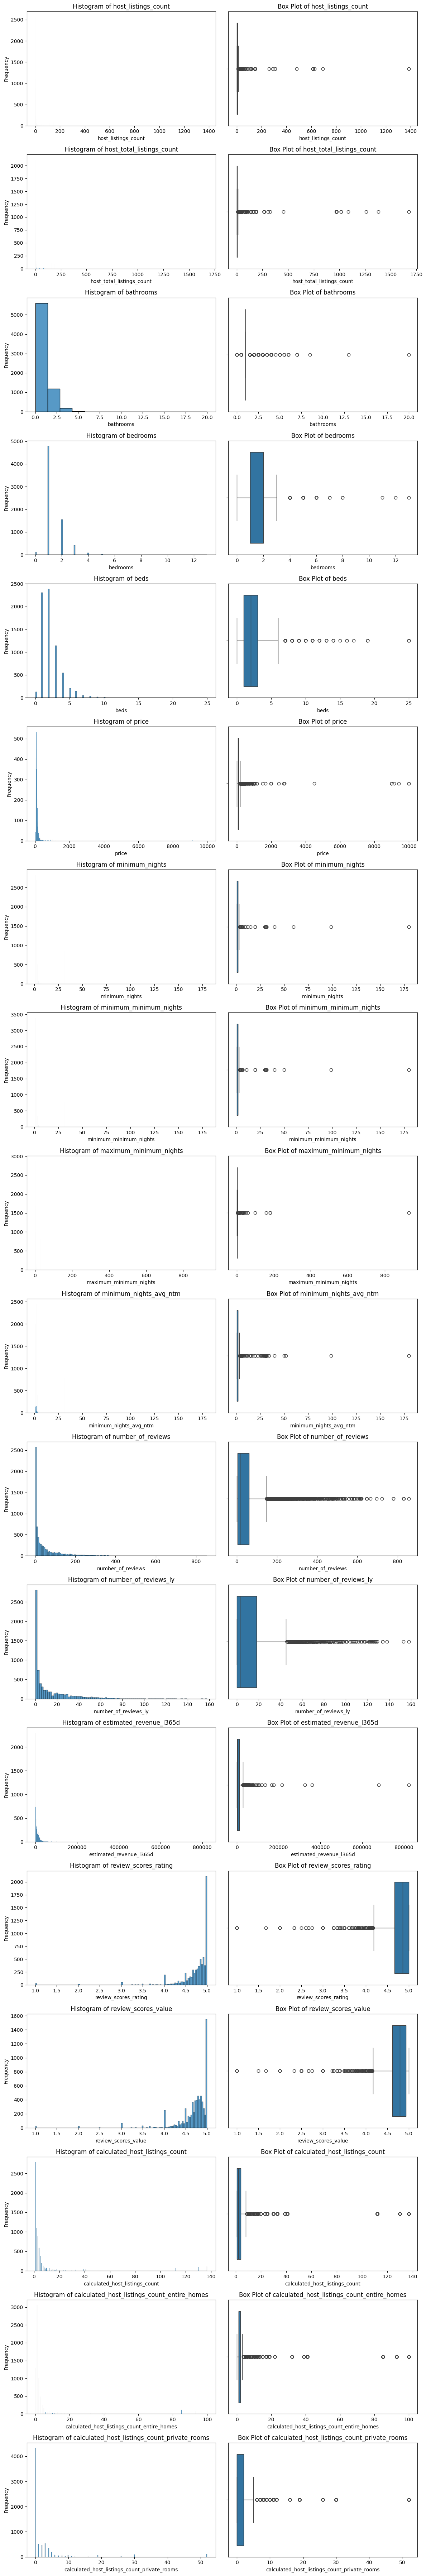

In [235]:
# Columns for plotting
cols_to_plot = outlier_columns
# cols_to_plot = ['host_listings_count', 'host_total_listings_count']

# Create subplots for histograms and box plots side by side
fig, axes = plt.subplots(len(cols_to_plot), 2, figsize=(12, 4 * len(cols_to_plot))) # 2 columns for hist and boxplot

for i, col in enumerate(cols_to_plot):
    # Histogram
    sns.histplot(data=df, x=col, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    # Box plot
    sns.boxplot(data=df, x=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'Box Plot of {col}')
    axes[i, 1].set_xlabel(col)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Outlier Removal

In [236]:
# Remove host_listing_counts above 200
df = df[df['host_listings_count'] <= 200]

In [237]:
# Remove bathrooms count above 10
df = df[df['bathrooms'] <= 10]

In [238]:
# Remove bedrooms count above 10
df = df[df['bedrooms'] <= 10]

In [239]:
# Remove beds above 19
df = df[df['beds'] <= 19]

In [240]:
# Remove minimum_nights above 50
df = df[df['minimum_nights'] <= 50]

In [241]:
# Remove calculated_host_listings_count_entire_homes above 30
df = df[df['calculated_host_listings_count_entire_homes'] <= 30]

In [242]:
# Remove calculated_host_listings_count_private_rooms above 15
df = df[df['calculated_host_listings_count_private_rooms'] <= 15]

In [243]:
# Check the shape of our dataframe
df.shape

(6560, 53)

In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6560 entries, 0 to 10637
Data columns (total 53 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   source                                        6560 non-null   object 
 1   host_since                                    6560 non-null   float64
 2   host_response_time                            6560 non-null   object 
 3   host_response_rate                            6560 non-null   float64
 4   host_acceptance_rate                          6560 non-null   float64
 5   host_is_superhost                             6560 non-null   object 
 6   host_listings_count                           6560 non-null   float64
 7   host_total_listings_count                     6560 non-null   float64
 8   host_has_profile_pic                          6560 non-null   object 
 9   host_identity_verified                        6560 non-null   objec

In [245]:
# Get a sense of each categorical variable's value_counts
df.select_dtypes(include='object').nunique()

,0
source,1
host_response_time,5
host_is_superhost,2
host_has_profile_pic,2
host_identity_verified,2
neighbourhood_cleansed,30
property_type,45
room_type,4
amenities,6391
has_availability,1


# Data Reduction

## Correlations

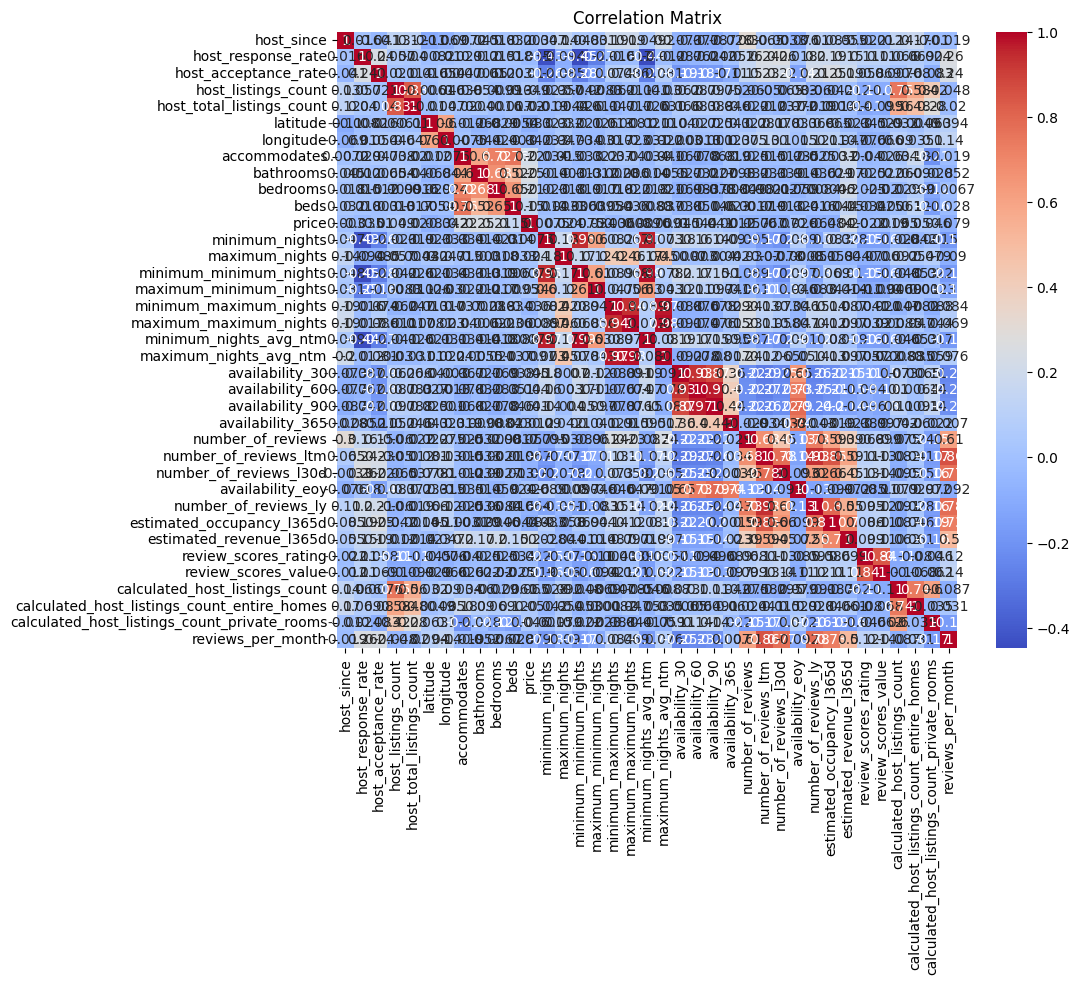

In [246]:
# Find correlations for all numeric datatypes
corr_matrix = df.select_dtypes(include=np.number).corr()

# plot the corr_matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [247]:
# Show the correlations that have high positve correlations not with itself
corr_matrix[corr_matrix > 0.8]

,host_since,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,reviews_per_month
host_since,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_response_rate,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_acceptance_rate,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_listings_count,NaN,NaN,NaN,1.000000,0.831383,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_total_listings_count,NaN,NaN,NaN,0.831383,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bathrooms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [248]:
# Visualize the correlation matrix in a table
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Filter for correlations over .8 (High Positive Correlation)
strong_corrs = corr_pairs[corr_pairs> 0.8]
strong_corrs = strong_corrs.drop_duplicates().sort_values(ascending=False)

# Show the correlations
strong_corrs

minimum_minimum_nights  minimum_nights_avg_ntm       0.986348
maximum_maximum_nights  maximum_nights_avg_ntm       0.983959
minimum_maximum_nights  maximum_nights_avg_ntm       0.972017
availability_60         availability_90              0.969077
minimum_nights          minimum_nights_avg_ntm       0.965594
                        minimum_minimum_nights       0.948868
minimum_maximum_nights  maximum_maximum_nights       0.938554
number_of_reviews_ltm   number_of_reviews_ly         0.934478
availability_30         availability_60              0.926536
                        availability_90              0.872993
number_of_reviews_ltm   reviews_per_month            0.855304
                        estimated_occupancy_l365d    0.845971
review_scores_rating    review_scores_value          0.837704
host_listings_count     host_total_listings_count    0.831383
dtype: float64

### Drop columns based on high correlations

In [249]:
# Drop minimum_minimum_nights, maximum_maximum_nights, host_total_listings_count,number_of_reviews_ly, calculated_host_listings_count from the dataset
df = df.drop(columns=['minimum_minimum_nights',
                      'maximum_minimum_nights',
                      'minimum_maximum_nights',
                      'maximum_maximum_nights',
                      'minimum_nights_avg_ntm',
                      'maximum_nights_avg_ntm',
                      'host_total_listings_count',
                      'number_of_reviews_ly',
                      'calculated_host_listings_count'])

# Numeric Data Standardization

In [250]:
# Show summary statistics for each numerical column
df.select_dtypes(include=["int64", "float64"]).describe()

,host_since,host_response_rate,host_acceptance_rate,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_value,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,reviews_per_month
count,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000
mean,2148.021341,83.689024,91.029826,3.866768,40.847458,14.250262,3.809299,1.222713,1.380488,2.255335,112.305183,5.356098,384.958841,14.409146,32.708689,53.303354,232.769207,55.289024,13.742835,1.515396,133.134909,81.597866,7846.402287,4.766828,4.705713,1.842988,1.193293,1.480119
std,1373.759202,35.612493,20.912958,6.520933,0.011378,0.019287,2.016415,0.563963,0.733231,1.560358,173.201308,9.712628,414.032059,9.065497,17.811511,25.873230,102.460006,90.146467,19.103274,2.229152,50.075600,90.721688,11561.770581,0.378619,0.413517,2.643251,2.121874,1.629555
min,13.000000,0.000000,0.000000,1.000000,40.793880,14.160030,1.000000,0.000000,0.000000,0.000000,13.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.010000
25%,787.000000,100.000000,92.750000,1.000000,40.840970,14.244520,2.000000,1.000000,1.000000,1.000000,68.000000,1.000000,30.000000,7.000000,18.000000,33.000000,153.000000,4.000000,1.000000,0.000000,102.000000,6.000000,636.000000,4.697500,4.640000,1.000000,0.000000,0.270000
50%,2252.000000,100.000000,100.000000,2.000000,40.848653,14.251371,4.000000,1.000000,1.000000,2.000000,87.000000,2.000000,365.000000,14.000000,34.000000,56.000000,254.000000,18.000000,5.000000,0.000000,144.000000,42.000000,3552.000000,4.870000,4.800000,1.000000,0.000000,0.930000
75%,3301.000000,100.000000,100.000000,4.000000,40.854115,14.261873,4.000000,1.000000,2.000000,3.000000,120.000000,2.000000,365.000000,22.000000,48.000000,76.000000,326.000000,65.000000,20.000000,2.000000,174.000000,144.000000,11988.000000,5.000000,4.940000,2.000000,2.000000,2.140000
max,5890.000000,100.000000,100.000000,108.000000,40.905010,14.346380,16.000000,8.500000,8.000000,19.000000,10000.000000,40.000000,1130.000000,30.000000,60.000000,90.000000,365.000000,856.000000,142.000000,16.000000,196.000000,255.000000,325296.000000,5.000000,5.000000,22.000000,12.000000,11.020000


In [251]:
# Collect our columns to standardize
cols_to_standardize = list(df.select_dtypes(include = ["float64", "int64"]).columns)

In [252]:
# Check our columns
cols_to_standardize

['host_since',
 'host_response_rate',
 'host_acceptance_rate',
 'host_listings_count',
 'latitude',
 'longitude',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'price',
 'minimum_nights',
 'maximum_nights',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'availability_eoy',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'review_scores_rating',
 'review_scores_value',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'reviews_per_month']

In [253]:
# Remove our target variable
cols_to_standardize.remove("price")

In [254]:
# Standardize all numeric columns
for col in cols_to_standardize:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

In [255]:
# Show summary statistics for each numerical column to show it worked
df.select_dtypes(include=["int64", "float64"]).describe()

,host_since,host_response_rate,host_acceptance_rate,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_value,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,reviews_per_month
count,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000,6560.000000
mean,0.363284,0.836890,0.910298,0.026792,0.482116,0.484207,0.187287,0.143849,0.172561,0.118702,112.305183,0.111695,0.339503,0.480305,0.545145,0.592259,0.637724,0.063496,0.096781,0.094712,0.679260,0.319992,0.024121,0.941707,0.926428,0.083772,0.099441,0.133526
std,0.233752,0.356125,0.209130,0.060943,0.102386,0.103496,0.134428,0.066349,0.091654,0.082124,173.201308,0.249042,0.367050,0.302183,0.296859,0.287480,0.280712,0.105434,0.134530,0.139322,0.255488,0.355771,0.035542,0.094655,0.103379,0.120148,0.176823,0.148007
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.131700,1.000000,0.927500,0.000000,0.423738,0.453394,0.066667,0.117647,0.125000,0.052632,68.000000,0.000000,0.024823,0.233333,0.300000,0.366667,0.419178,0.003509,0.007042,0.000000,0.520408,0.023529,0.001955,0.924375,0.910000,0.045455,0.000000,0.023615
50%,0.380977,1.000000,1.000000,0.009346,0.492872,0.490159,0.200000,0.117647,0.125000,0.105263,87.000000,0.025641,0.321809,0.466667,0.566667,0.622222,0.695890,0.019883,0.035211,0.000000,0.734694,0.164706,0.010919,0.967500,0.950000,0.045455,0.000000,0.083560
75%,0.559469,1.000000,1.000000,0.028037,0.542024,0.546516,0.200000,0.117647,0.250000,0.157895,120.000000,0.025641,0.321809,0.733333,0.800000,0.844444,0.893151,0.074854,0.140845,0.125000,0.887755,0.564706,0.036853,1.000000,0.985000,0.090909,0.166667,0.193460
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Export CSV

In [257]:
# Export the df to a finalized csv
df.to_csv("finalized_df.csv")